# 📊 OASIS INFOBYTE — Data Analytics
## Level 1 • Task 1 — EDA on Retail Sales Data

**Objective:** Perform a thorough Exploratory Data Analysis to uncover sales patterns,
customer behaviour trends and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook.

> **Dataset note:** The standard Kaggle Retail Sales Dataset has customer age/gender
> and product **category**, but not individual product names. The notebook therefore
> checks for a product-name column. If it is absent, it transparently analyzes product
> categories instead of inventing product names.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE_DIR = Path("..")
DATA_PATH = BASE_DIR / "data" / "retail_sales_dataset.csv"
CHART_DIR = BASE_DIR / "output" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download retail_sales_dataset.csv and place it in the data folder."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Initial Inspection
We first inspect the dataset shape, column types, missing values and basic structure.

In [2]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("null_count"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.head())

Shape: (1000, 9)

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:


,dtype
Transaction ID,int64
Date,str
Customer ID,str
Gender,str
Age,int64
Product Category,str
Quantity,int64
Price per Unit,int64
Total Amount,int64



Missing values:


,null_count
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0



Duplicate rows: 0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Observation
The inspection above confirms the number of records and variables, identifies the
data types that may require conversion, and highlights any missing or duplicated
records before analysis.

In [3]:
# Standardize the expected columns if present
df.columns = [c.strip() for c in df.columns]

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_candidates = ["Age", "Quantity", "Price per Unit", "Total Amount", "Sales", "Revenue"]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


None

## 2. Descriptive Statistics
For every numerical variable, calculate mean, median, mode and standard deviation.

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in numeric_cols],
    "Std_Dev": df[numeric_cols].std()
})

display(stats)

,Mean,Median,Mode,Std_Dev
Transaction ID,500.500,500.5,1,288.819436
Age,41.392,42.0,43,13.681430
Quantity,2.514,3.0,4,1.132734
Price per Unit,179.890,50.0,50,189.681356
Total Amount,456.000,135.0,50,559.997632


### Observation
Mean and median show the central tendency of each numerical variable, while the
standard deviation indicates how widely values vary. Large differences between
mean and median can indicate skewness or unusually high/low transactions.

## 3. Time-Series Analysis — Monthly Sales

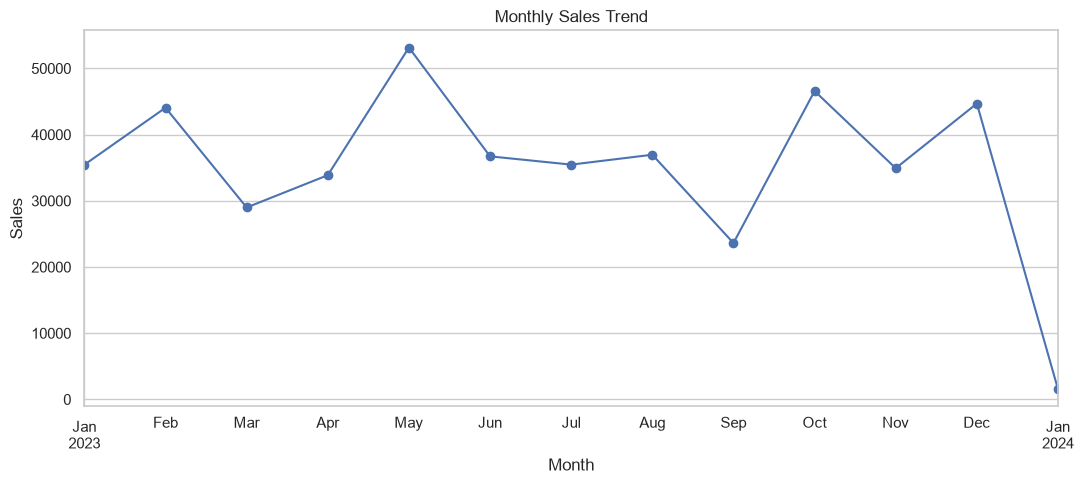

,Monthly Sales
Date,
2023-01-01,35450
2023-02-01,44060
2023-03-01,28990
2023-04-01,33870
2023-05-01,53150
2023-06-01,36715
2023-07-01,35465
2023-08-01,36960
2023-09-01,23620


In [5]:
sales_col = "Total Amount" if "Total Amount" in df.columns else (
    "Sales" if "Sales" in df.columns else "Revenue"
)

if "Date" not in df.columns or sales_col not in df.columns:
    raise ValueError("Date and a sales/revenue column are required for time-series analysis.")

monthly_sales = (
    df.dropna(subset=["Date", sales_col])
      .set_index("Date")[sales_col]
      .resample("MS")
      .sum()
)

plt.figure(figsize=(11, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_monthly_sales_trend.png", dpi=150)
plt.show()

display(monthly_sales.to_frame("Monthly Sales"))

### Observation
The monthly line chart makes peaks, dips and seasonal movement visible. These
changes can help a retailer plan inventory, promotions and staffing around
high- and low-demand periods.

## 4. Time-Series Analysis — Quarterly Sales

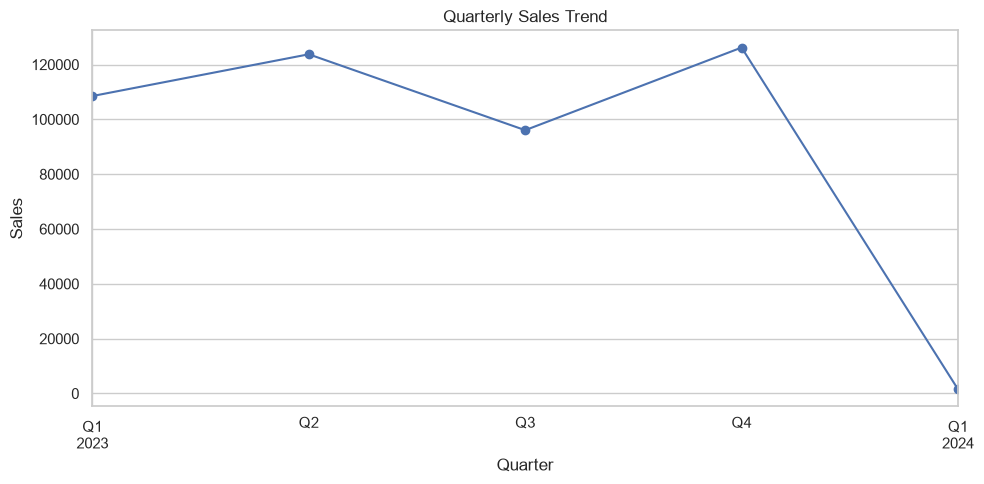

,Quarterly Sales
Date,
2023-01-01,108500
2023-04-01,123735
2023-07-01,96045
2023-10-01,126190
2024-01-01,1530


In [6]:
quarterly_sales = (
    df.dropna(subset=["Date", sales_col])
      .set_index("Date")[sales_col]
      .resample("QS")
      .sum()
)

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind="line", marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_quarterly_sales_trend.png", dpi=150)
plt.show()

display(quarterly_sales.to_frame("Quarterly Sales"))

### Observation
Quarterly aggregation smooths short-term variation and is useful for comparing
broader business performance. The strongest quarter can be used as a benchmark
for future sales planning.

## 5. Customer Demographics — Age Groups and Gender

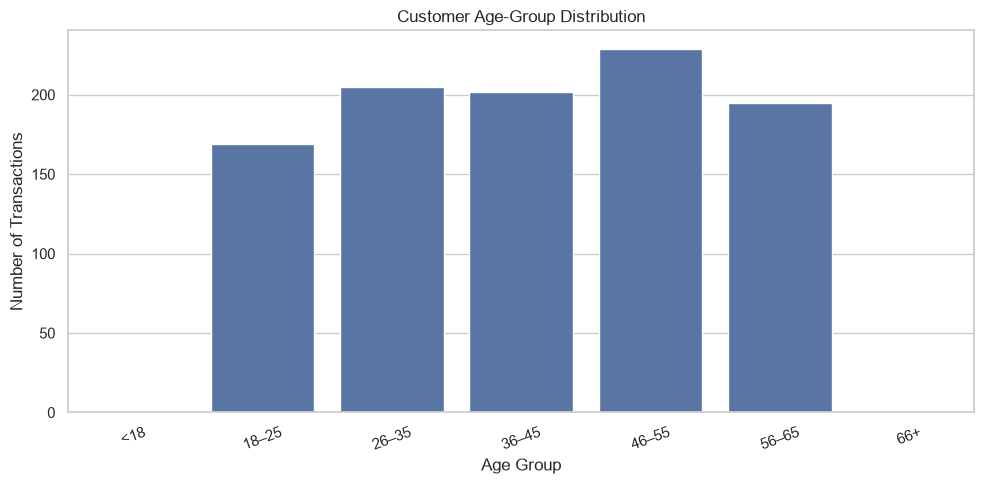

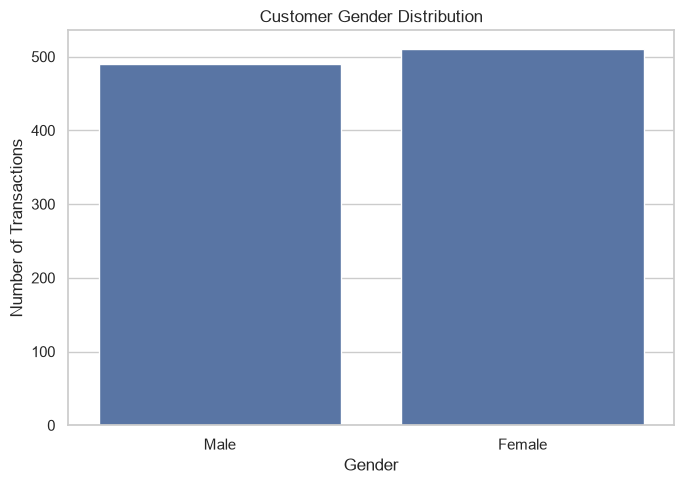

,Total Sales
Gender,
Female,232840
Male,223160


In [7]:
if "Age" in df.columns:
    bins = [0, 17, 25, 35, 45, 55, 65, np.inf]
    labels = ["<18", "18–25", "26–35", "36–45", "46–55", "56–65", "66+"]
    df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, include_lowest=True)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x="Age Group", order=labels)
    plt.title("Customer Age-Group Distribution")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(CHART_DIR / "03_customer_age_groups.png", dpi=150)
    plt.show()

if "Gender" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df, x="Gender")
    plt.title("Customer Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "04_gender_distribution.png", dpi=150)
    plt.show()

if "Gender" in df.columns and sales_col in df.columns:
    gender_sales = df.groupby("Gender")[sales_col].sum().sort_values(ascending=False)
    display(gender_sales.to_frame("Total Sales"))

### Observation
Age-group and gender distributions reveal which customer demographics generate
the most transactions. Combining transaction count with revenue is more useful
than relying on counts alone, because a smaller group can still generate higher
value purchases.

## 6. Product Analysis

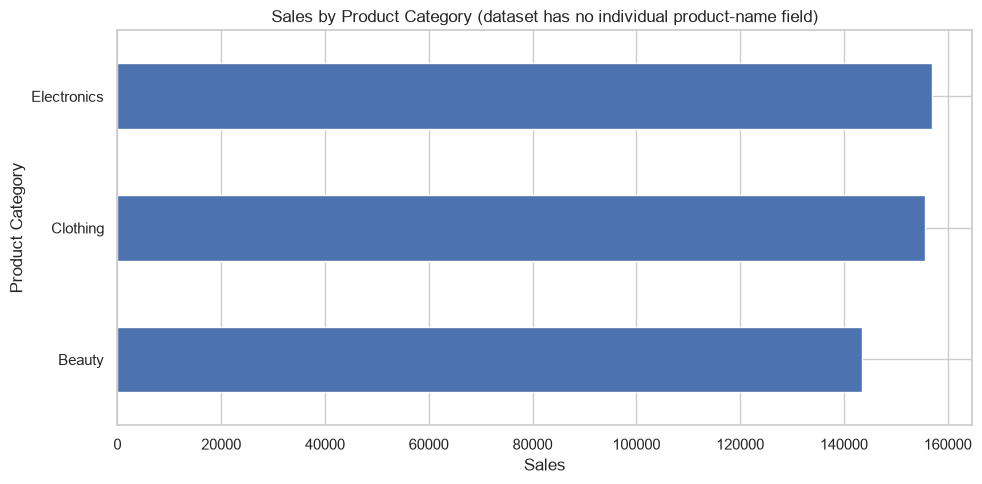

,Sales
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [8]:
product_col = next(
    (c for c in ["Product Name", "Product", "Item"] if c in df.columns),
    None
)

if product_col:
    top_products = (
        df.groupby(product_col)[sales_col]
          .sum()
          .sort_values(ascending=False)
          .head(10)
    )
    title = "Top 10 Best-Selling Products by Revenue"
else:
    top_products = (
        df.groupby("Product Category")[sales_col]
          .sum()
          .sort_values(ascending=False)
    )
    title = "Sales by Product Category (dataset has no individual product-name field)"

plt.figure(figsize=(10, 5))
top_products.sort_values().plot(kind="barh")
plt.title(title)
plt.xlabel("Sales")
plt.ylabel(product_col if product_col else "Product Category")
plt.tight_layout()
plt.savefig(CHART_DIR / "05_product_analysis.png", dpi=150)
plt.show()

display(top_products.to_frame("Sales"))

### Important dataset limitation
The standard Kaggle `retail_sales_dataset.csv` contains `Product Category` but does
not contain an individual `Product Name`/`Product` field. Therefore this notebook
**does not invent product names**. It reports category-level sales when that field
is absent. If a dataset containing product names is supplied, the same code
automatically switches to the required Top 10 product analysis.

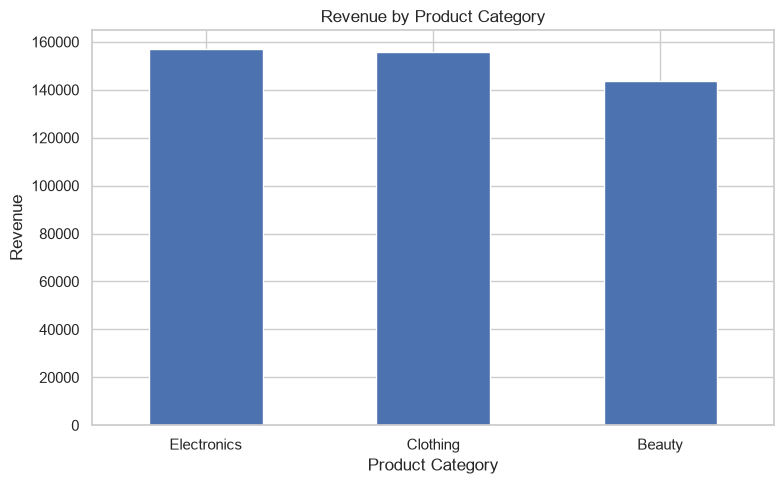

,Revenue
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [9]:
if "Product Category" in df.columns:
    category_revenue = df.groupby("Product Category")[sales_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    category_revenue.plot(kind="bar")
    plt.title("Revenue by Product Category")
    plt.xlabel("Product Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(CHART_DIR / "06_revenue_by_category.png", dpi=150)
    plt.show()

    display(category_revenue.to_frame("Revenue"))

### Observation
The category chart identifies the revenue-driving areas of the product portfolio.
The business can prioritize inventory and marketing around strong categories while
reviewing pricing and promotion strategy for weaker categories.

## 7. Correlation Heatmap

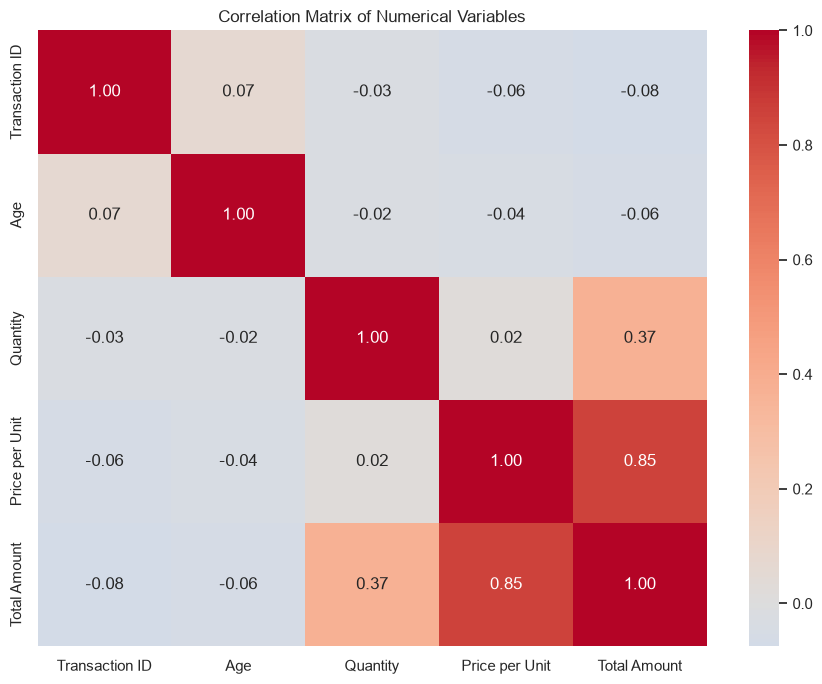

In [10]:
corr_cols = df.select_dtypes(include=np.number).columns
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_correlation_heatmap.png", dpi=150)
plt.show()

### Observation
The heatmap shows which numerical variables move together. In retail data,
quantity and total sales are expected to be positively related, while age or
unit price may show weaker or more context-dependent relationships. Correlation
does not prove causation.

## 8. Additional Visualization — Average Spend by Age Group

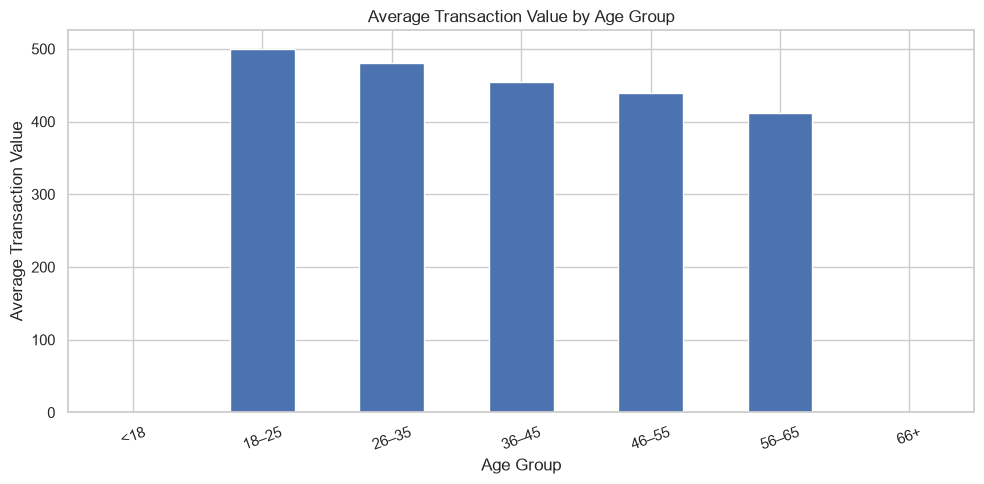

,Average Transaction Value
Age Group,
<18,NaN
18–25,500.295858
26–35,480.390244
36–45,454.801980
46–55,439.694323
56–65,412.358974
66+,NaN


In [11]:
if "Age Group" in df.columns:
    age_spend = (
        df.groupby("Age Group", observed=False)[sales_col]
          .mean()
          .reindex(labels)
    )

    plt.figure(figsize=(10, 5))
    age_spend.plot(kind="bar")
    plt.title("Average Transaction Value by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Average Transaction Value")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(CHART_DIR / "08_average_spend_by_age_group.png", dpi=150)
    plt.show()

    display(age_spend.to_frame("Average Transaction Value"))

### Non-obvious insight
Average transaction value can differ from transaction volume by age group. This
helps identify groups that may be smaller in number but more valuable per purchase,
which can support targeted offers and customer retention campaigns.

## 9. Business Recommendations

Based on the completed analysis, the final recommendations should be tied to the
actual values visible in the tables and charts above. Use at least these three
business actions:

1. **Inventory and promotion planning:** allocate more inventory and promotional
   budget to the strongest sales categories and high-performing periods.
2. **Demographic targeting:** tailor campaigns to the age/gender groups showing
   stronger transaction value or purchase activity rather than treating all
   customers identically.
3. **Seasonal planning:** use the monthly and quarterly trend to prepare stock,
   staffing and campaigns before recurring high-demand periods.

> Before submission, replace generic wording above with the exact category,
> age-group and period names observed in your executed notebook results.

## 10. Final Checklist

- [x] Load dataset and perform initial inspection
- [x] Shape, column types and null-value check
- [x] Mean, median, mode and standard deviation
- [x] Monthly sales trend
- [x] Quarterly sales trend
- [x] Customer age-group and gender analysis
- [x] Product/category analysis
- [x] Correlation heatmap
- [x] Additional visualization
- [x] Written observations after charts
- [x] At least 3 actionable business recommendations

**Run the notebook from top to bottom before submission and make sure every chart
and output cell executes successfully.**